In [4]:
import os,json, glob, random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import torch.nn.functional as F
import shap 
from functools import reduce
import random
import matplotlib.pyplot as plt

In [5]:
# Mapping for 20 standard amino acids
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

# # Directory setup
# os.makedirs("cnn_models", exist_ok=True)
# os.makedirs("cnn_results", exist_ok=True)



In [6]:
# CNN model
# class ProteinCNN(nn.Module):
#     def __init__(self, input_dim=20):
#         super(ProteinCNN, self).__init__()
#         self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=5, padding=2)
#         self.relu = nn.ReLU()
#         self.pool = nn.AdaptiveMaxPool1d(1)
#         self.fc = nn.Linear(64, 1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         x = self.relu(self.conv1(x))
#         x = self.pool(x).squeeze(-1)
#         x = self.sigmoid(self.fc(x))
#         return x.squeeze()

# Dataset class


class ProteinDataset(Dataset):
    """
    • Stores variable-length AA sequences + binary labels.
    • At __getitem__ time, returns:
          (one_hot_tensor  : torch.float32 [20, L_pad],
           label           : torch.float32 [])
    • All samples are padded / truncated to self.seq_len so they
      can be stacked into a batch.  self.seq_len = max length in
      the provided list.
    """
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

        lengths = [len(seq) for seq in sequences]
        min_len = min(lengths)
        max_len = max(lengths)

        if max_len - min_len > 2:
            raise ValueError(f"Sequences vary too much in length! Found lengths: {set(lengths)}")

        self.seq_len = max_len  # allow minor difference (pad shorter sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]

        onehot = np.zeros((20, self.seq_len), dtype=np.float32)
        for i, aa in enumerate(seq):
            if i >= self.seq_len:  # (safety) but should never happen
                break
            if aa in AA_TO_INDEX:
                onehot[AA_TO_INDEX[aa], i] = 1.0

        return torch.tensor(onehot), torch.tensor(label, dtype=torch.float32)



In [7]:

import torch, torch.nn as nn, torch.nn.functional as F

class ProteinCNN1x1(nn.Module):
    """
    One-dimensional MDCNN-style network that expects input shaped
    (batch, C=in_dim, L_total).   concatenate multi-locus sequences
    along the *length* axis, so a single Conv1d stack is enough.
    """
    def __init__(self, seq_len: int, in_dim: int = 20, stem_out: int = 64):
        super().__init__()
        self.stem  = nn.Conv1d(in_dim, stem_out, 1)          # 1×1 remix
        self.conv1 = nn.Conv1d(stem_out, 64, 12, padding=6)  # RF ≈ 12
        self.pool1 = nn.MaxPool1d(3)
        self.conv2 = nn.Conv1d(64, 32, 3, padding=1)
        self.conv3 = nn.Conv1d(32, 32, 3, padding=1)
        self.pool2 = nn.MaxPool1d(3)

        # figure out flattened feature dim once
        with torch.no_grad():
            dummy = torch.zeros(1, in_dim, seq_len)
            flat  = self._forward_feat(dummy).numel()
        self.fc1 = nn.Linear(flat, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc_out = nn.Linear(256, 1)

    # ---- internal feature extractor ---------------------------------
    def _forward_feat(self, x):
        x = self.stem(x)
        x = F.relu(self.conv1(x)); x = self.pool1(x)
        x = F.relu(self.conv2(x)); x = F.relu(self.conv3(x)); x = self.pool2(x)
        return x

    # ---- forward -----------------------------------------------------
    def forward(self, x):                       # x: (B,C,L)
        x = self._forward_feat(x)
        x = torch.flatten(x, 1)                 # (B, flat)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc_out(x).squeeze(-1)       # logits


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
# Deduplicate by raw sequence + label (to keep R/S separate if same seq)
def dedup_seq_indices_from_df(df, seq_col="Protein_Sequence", y_col="Phenotype", cache_name=None, out_dir="../data/latest/results/interpretability/cnn/dedup_ohe"):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    cache_path = out_dir / f"{cache_name}_dedup_indices.npy" if cache_name else None

    if cache_path and cache_path.exists():
        idx = np.load(cache_path).tolist()
        print(f"[dedup] loaded cached indices for {cache_name}: {len(df)} → {len(idx)}")
        return idx

    seen, keep = set(), []
    for i, row in df.reset_index(drop=True).iterrows():
        key = (row[seq_col], int(row[y_col] == "R") if isinstance(row[y_col], str) else int(row[y_col]))
        if key not in seen:
            seen.add(key); keep.append(i)

    if cache_path:
        np.save(cache_path, np.array(keep, dtype=int))
        print(f"[dedup] saved indices for {cache_name}: {len(df)} → {len(keep)} "
              f"({len(df)-len(keep)} removed, {100*(len(df)-len(keep))/max(1,len(df)):.1f}% reduction)")
    return keep

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_bg_explain_indices(y, bg_frac=0.10, seed=42, max_bg=None):
    """
    Return disjoint (bg_idx, ex_idx) with BG ~= bg_frac of the pool.
    If both classes exist, BG is stratified so it contains both R/S.
    If only one class exists, it just does a random split.
    Optionally cap BG at max_bg (keeps stratification).
    Ensures at least one sample remains for EX.
    """
    y = np.asarray(y, dtype=int)
    N = len(y)
    assert N >= 2, "Need at least 2 samples to split."
    idx = np.arange(N)

    # (1) initial BG/EX split
    if len(np.unique(y)) > 1:
        bg_idx, ex_idx = train_test_split(
            idx, train_size=bg_frac, stratify=y, random_state=seed
        )
    else:
        rng = np.random.default_rng(seed)
        perm = rng.permutation(idx)
        cut = max(1, int(round(bg_frac * N)))
        bg_idx, ex_idx = perm[:cut], perm[cut:]

    # (2) optional cap on BG; keep stratification within BG if possible
    if max_bg is not None and len(bg_idx) > max_bg:
        if len(np.unique(y[bg_idx])) > 1:
            bg_idx, _ = train_test_split(
                bg_idx, train_size=max_bg, stratify=y[bg_idx], random_state=seed
            )
        else:
            # single-class BG; random cap
            rng = np.random.default_rng(seed)
            bg_idx = rng.choice(bg_idx, size=max_bg, replace=False)

        # recompute EX as complement
        mask = np.ones(N, dtype=bool)
        mask[bg_idx] = False
        ex_idx = np.where(mask)[0]

    # (3) ensure EX is non-empty
    if len(ex_idx) == 0:
        ex_idx = np.array([bg_idx[-1]])
        bg_idx = bg_idx[:-1]

    return np.asarray(bg_idx), np.asarray(ex_idx)


In [11]:

# def disjoint_bg_explain_indices(n_samples, bg_frac=0.10, seed=42, min_bg=1, min_explain=1, max_bg=150):
#     rng = np.random.default_rng(seed)
#     perm = rng.permutation(n_samples)
#     bg_target = max(min_bg, int(round(bg_frac * n_samples)))
#     if max_bg is not None:
#         bg_target = min(bg_target, max_bg)
#     # ensure at least one to explain
#     bg_target = min(bg_target, n_samples - min_explain) if n_samples > min_explain else max(1, n_samples // 2)
#     bg_idx = perm[:bg_target]
#     explain_idx = perm[bg_target:]
#     return bg_idx, explain_idx, bg_target

# ─────────────────────────────────────────────────────────────
def _per_gene_lengths_onehot(drug, seq_len):
    genes = DRUG2GENES[drug]
    if len(genes) == 1:
        return genes, [seq_len]
    # recover per-gene lengths 
    df = _build_drug_df(drug)
    lengths = [len(df[f"seq_{g}"].iloc[0]) for g in genes]
    assert sum(lengths) == seq_len, f"{drug}: per-gene lengths {lengths} sum to {sum(lengths)} != seq_len {seq_len}"
    print("[per-gene lengths]", ", ".join(f"{g}={L}" for g, L in zip(genes, lengths)), f"(sum={sum(lengths)})")
    return genes, lengths

# ─────────────────────────────────────────────────────────────
def shap_single_pool_onehot(model, pool_ds, gene_names, per_gene_lengths, 
                            bg_frac=0.10, seed=42, max_bg=150, run_name="", device=device):
    model = model.to(device).eval()
    N = len(pool_ds)
    assert N >= 2, "Need at least 2 unique samples to split background/explain."
    # labels from the unique pool
    y_pool = np.array([int(pool_ds[i][1]) for i in range(len(pool_ds))], dtype=int)
    
    # bg_idx, ex_idx, bg_target = disjoint_bg_explain_indices(N, bg_frac=bg_frac, seed=seed, max_bg=max_bg)
    bg_idx, ex_idx = stratified_bg_explain_indices(
        y_pool, bg_frac=bg_frac, seed=seed, max_bg=max_bg
    )
    # meta = {
    #     "run": run_name,
    #     "N_unique": int(N),
    #     "bg_frac": float(bg_frac),
    #     "max_bg": int(max_bg) if max_bg is not None else None,
    #     "bg_target": int(bg_target),
    #     "actual_bg": int(len(bg_idx)),
    #     "actual_explain": int(len(ex_idx)),
    #     "seed": int(seed),
    # }
    # print(f"[SHAP] {run_name} | N={N} | BG={len(bg_idx)} EX={len(ex_idx)} (bg_frac≈{bg_frac:.0%}, cap={max_bg})")
    meta = {
        "N_unique": int(len(y_pool)),
        "bg_size": int(len(bg_idx)),
        "ex_size": int(len(ex_idx)),
        "bg_pos": int((y_pool[bg_idx] == 1).sum()),
        "bg_neg": int((y_pool[bg_idx] == 0).sum()),
        "ex_pos": int((y_pool[ex_idx] == 1).sum()),
        "ex_neg": int((y_pool[ex_idx] == 0).sum()),
        "seed": int(seed),
        "bg_frac": float(bg_frac),
        "max_bg": None if max_bg is None else int(max_bg),
    }
    print(f"[split] BG={meta['bg_size']} (R={meta['bg_pos']}, S={meta['bg_neg']}) | "
          f"EX={meta['ex_size']} (R={meta['ex_pos']}, S={meta['ex_neg']})")
    # tensors
    background = torch.stack([pool_ds[int(i)][0] for i in bg_idx]).to(device)
    xs         = torch.stack([pool_ds[int(i)][0] for i in ex_idx]).to(device)
    ys         = [int(pool_ds[int(i)][1]) for i in ex_idx]

    explainer = shap.DeepExplainer(Wrapped(model), [background])
    sv  = explainer.shap_values([xs], check_additivity=False)[0]  # (E, C, L)
    imp = np.abs(sv).sum(axis=1)                                  # (E, L)

    out = {
        "sample_idx": list(map(int, ex_idx)),
        "label": ys,
        "importance_full": list(imp)
    }
    if len(gene_names) > 1:
        cuts = np.cumsum([0] + per_gene_lengths)
        for gi, g in enumerate(gene_names):
            out[f"importance_{g}"] = [imp[n, cuts[gi]:cuts[gi+1]] for n in range(imp.shape[0])]
    return pd.DataFrame(out), meta

# ─────────────────────────────────────────────────────────────
# Generic driver for CNN and Transformer
def compute_shap_onehot(
    drug,
    load_model_fn,           # callable: returns (model, seq_len)
    model_tag,               # "cnn_ohe" or "transformer_ohe" (used in paths)
    bg_frac=0.10, seed=42, max_bg=150,
    out_root="data/latest/results"
):
    # 1) load trained model + one-hot sequence length
    model, seq_len = load_model_fn(drug)

    # 2) rebuild splits → concat → dedup unique sequences
    #    Expect a function that returns train/test DataFrames with 'Protein_Sequence' and 'Phenotype'
    train_df, test_df = build_train_test_split(drug)  #
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    keep = dedup_seq_indices_from_df(full_df, seq_col="Protein_Sequence", y_col="Phenotype",
                                     cache_name=f"{drug}_ohe_full")
    full_df_u = full_df.iloc[keep].reset_index(drop=True)

    # 3) build the one-hot dataset from UNIQUE sequences
    full_ds = ProteinDataset(
        full_df_u["Protein_Sequence"].tolist(),
        (full_df_u["Phenotype"] == "R").astype(int).tolist()
    )

    # 4) per-gene lengths (needed for multi-gene slicing)
    gene_names, per_gene_lengths = _per_gene_lengths_onehot(drug, seq_len)

    # 5) compute SHAP (single unique pool, disjoint BG/EX)
    out_dir = Path(out_root) / "interpretability" / model_tag
    out_dir.mkdir(parents=True, exist_ok=True)
    run_name = f"{drug}_{model_tag}"

    shap_df, meta = shap_single_pool_onehot(
        model, full_ds, gene_names, per_gene_lengths,
        bg_frac=bg_frac, seed=seed, max_bg=max_bg, run_name=run_name, device=device
    )

    # 6) save results
    pkl_path  = out_dir / f"{drug}_{model_tag}_shap_all.pkl"
    meta_path = out_dir / f"{drug}_{model_tag}_shap_all_meta.json"
    shap_df.to_pickle(pkl_path, protocol=4)
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[save] {pkl_path}")
    print(f"[save] {meta_path}")





In [12]:
class Wrapped(nn.Module):
    """
    Tiny adapter so SHAP sees output shape (B,1) instead of (B,)
    """
    def __init__(self, base): super().__init__(); self.base = base
    def forward(self, x):     return self.base(x).unsqueeze(1)

In [13]:
def load_onehot_model(drug, run_dir="../data/latest/results/prediction/cnn/cnn_models"):
    """
    Reload saved one-hot CNN for a drug.
    Returns (model, seq_len).
    """
    # detect sequence length from a saved meta or directly from dataset
    # (here: read one sequence to infer length)
    seqs = _build_drug_df(drug)["Protein_Sequence"].tolist()
    seq_len = max(len(s) for s in seqs)

    model = ProteinCNN1x1(seq_len=seq_len, in_dim=20).to(device)
    model_path = Path(run_dir) / f"{drug}_cnn.pt"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    return model, seq_len

In [ ]:

def compute_shap_cnn_onehot(drug, bg_frac=0.10, seed=42, max_bg=150, out_root="../data/latest/results"):
    return compute_shap_onehot(
        drug, load_model_fn=load_onehot_model, model_tag="cnn",
        bg_frac=bg_frac, seed=seed, max_bg=max_bg, out_root=out_root
    )

    # TODO = ["rifampicin","ethionamide","ethambutol","isoniazid","pyrazinamide",
    #         "amikacin","capreomycin","streptomycin","levofloxacin","moxifloxacin"]
# ─────────────────────────────────────────────────────────────
# Example driver
if __name__ == "__main__":
    TODO = ["rifampicin","ethionamide","ethambutol","isoniazid","pyrazinamide",
            "amikacin","capreomycin","streptomycin","levofloxacin","moxifloxacin"]

    # CNN one-hot
    for drug in TODO:
        compute_shap_cnn_onehot(drug, bg_frac=0.10, seed=42, max_bg=160)

In [15]:





# def shap_per_residue(model, train_ds, val_ds,
#                      background_size=100, explain_samples=200,
#                      per_gene_lengths=None, gene_names=None,
#                      device="cuda"):
#     """
#     Returns a DataFrame with columns:
#        sample_idx , label , importance_full , importance_<gene1> , …
#     * importance_… columns hold np.ndarray vectors with per-residue |SHAP|.
#     """
#     model = model.to(device).eval()

#     # ---- (1) pick SHAP background from *training* set ------------
#     B = min(background_size, len(train_ds))
#     bg_idx = random.sample(range(len(train_ds)), B)
#     background = torch.stack([train_ds[i][0] for i in bg_idx]).to(device)

#     explainer = shap.DeepExplainer(Wrapped(model), [background])

#     # ---- (2) pick validation samples to explain ------------------
#     E = min(explain_samples, len(val_ds))
#     samp_idx = random.sample(range(len(val_ds)), E)
#     xs = torch.stack([val_ds[i][0] for i in samp_idx]).to(device)
#     ys = [val_ds[i][1] for i in samp_idx]

#     # ---- (3) compute SHAP ---------------------------------------
#     sv  = explainer.shap_values([xs], check_additivity=False)[0]   # (E,C,L)
#     imp = np.abs(sv).sum(axis=1)                                   # (E,L)

#     out = {
#         "sample_idx"      : samp_idx,
#         "label"           : [int(y) for y in ys],
#         "importance_full" : list(imp),
#     }

#     # ---- (4) slice per-gene chunks if needed ---------------------
#     if per_gene_lengths is not None:
#         cuts = np.cumsum([0] + per_gene_lengths)                  # e.g. [0,2517,4545]
#         for gi, g in enumerate(gene_names):
#             out[f"importance_{g}"] = [imp[n, cuts[gi]:cuts[gi+1]] for n in range(E)]

#     return pd.DataFrame(out)

In [16]:


# def dedup_and_save_indices(ds, name, out_dir="data/latest/results/dedup", force=False):
#     """
#     Deduplicate a dataset by exact sequence+label.
#     Saves indices to .npy and logs the reduction to a CSV file.

#     If indices already exist, they are loaded instead (unless force=True).
#     Log is overwrite-safe: updates existing row for the dataset.
#     """
#     out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
#     out_path = out_dir / f"cnn_{name}_dedup_indices.npy"
#     log_path = out_dir / "cnn_dedup_log.csv"

#     # --- (1) use cache if available ---
#     if out_path.exists() and not force:
#         uniq_indices = np.load(out_path, allow_pickle=True).tolist()
#         print(f"[{name}] using cached dedup indices ({len(uniq_indices)} sequences)")
#         return uniq_indices

#     # --- (2) compute fresh dedup ---
#     uniq_indices, seen = [], set()
#     for i in range(len(ds)):
#         x, y = ds[i]
#         key = (x.numpy().tobytes(), int(y))  # exact tensor bytes + label
#         if key not in seen:
#             seen.add(key)
#             uniq_indices.append(i)

#     np.save(out_path, uniq_indices)

#     # --- (3) prepare log row ---
#     new_row = {
#         "Dataset": name,
#         "Original_Size": len(ds),
#         "Dedup_Size": len(uniq_indices),
#         "Reduction": len(ds) - len(uniq_indices),
#         "Fraction_Removed": round(1 - len(uniq_indices)/len(ds), 3)
#     }

#     # --- (4) write/overwrite log ---
#     if log_path.exists():
#         log_df = pd.read_csv(log_path)
#         # remove existing row for this dataset if present
#         log_df = log_df[log_df["Dataset"] != name]
#         log_df = pd.concat([log_df, pd.DataFrame([new_row])], ignore_index=True)
#         log_df.to_csv(log_path, index=False)
#     else:
#         pd.DataFrame([new_row]).to_csv(log_path, index=False)

#     print(f"[{name}] deduplicated {len(ds)} → {len(uniq_indices)} "
#           f"({len(ds)-len(uniq_indices)} removed, "
#           f"{100*(1-len(uniq_indices)/len(ds)):.1f}% reduction)")

#     return uniq_indices


In [17]:
# def compute_shap_cnn_onehot(drug, background_frac=1.0, explain_frac=1.0,
#                             out_root="data/latest/results"):
#     """
#     Compute SHAP for saved one-hot CNN model, with cached dedup indices.
#     Produces:
#       - {drug}_cnn_shap_all.pkl   (exploratory: train+test)
#       - {drug}_cnn_shap_test.pkl  (deployment: test-only)
#     """
#     # --- load trained model ---
#     model, seq_len = load_onehot_model(drug)

#     # --- rebuild train/test splits ---
#     train_df, test_df = build_train_test_split(drug)

#     train_ds = ProteinDataset(
#         train_df["Protein_Sequence"].tolist(),
#         (train_df["Phenotype"] == "R").astype(int).tolist()
#     )
#     test_ds = ProteinDataset(
#         test_df["Protein_Sequence"].tolist(),
#         (test_df["Phenotype"] == "R").astype(int).tolist()
#     )
#     full_ds = ProteinDataset(
#         train_df["Protein_Sequence"].tolist() + test_df["Protein_Sequence"].tolist(),
#         (train_df["Phenotype"] == "R").astype(int).tolist() + 
#         (test_df["Phenotype"] == "R").astype(int).tolist()
#     )

#     out_path = Path(f"{out_root}/interpretability/cnn")
#     out_path.mkdir(parents=True, exist_ok=True)

#     # --- deduplicate (cached if exists) ---
#     train_idx = dedup_and_save_indices(train_ds, f"{drug}_train")
#     test_idx  = dedup_and_save_indices(test_ds,  f"{drug}_test")
#     full_idx  = dedup_and_save_indices(full_ds,  f"{drug}_full")

#     train_ds = torch.utils.data.Subset(train_ds, train_idx)
#     test_ds  = torch.utils.data.Subset(test_ds,  test_idx)
#     full_ds  = torch.utils.data.Subset(full_ds,  full_idx)

#     # --- compute per-gene lengths & names ---
#     gene_names = DRUG2GENES[drug]
#     if len(gene_names) == 1:
#         per_gene_lengths = [seq_len]
#     else:
#         # use _build_drug_df to recover per-gene sequence lengths
#         df = _build_drug_df(drug)
#         per_gene_lengths = [len(df[f"seq_{g}"].iloc[0]) for g in gene_names]

#         # sanity check
#         total_len = sum(per_gene_lengths)
#         assert total_len == seq_len, \
#             f"{drug}: expected {seq_len}, got {total_len}"

#         # verbose logging
#         lengths_str = ", ".join(f"{g}={L}" for g, L in zip(gene_names, per_gene_lengths))
#         print(f"[per-gene lengths] {drug}: {lengths_str} (sum={total_len}, expected={seq_len})")

#     # --- exploratory SHAP (train+test) ---
#     bg_size = max(1, int(len(train_ds) * background_frac))
#     ex_size = max(1, int(len(full_ds)  * explain_frac))
#     shap_all = shap_per_residue(
#         model=model, train_ds=train_ds, val_ds=full_ds,
#         background_size=bg_size, explain_samples=ex_size,
#         per_gene_lengths=per_gene_lengths if len(gene_names) > 1 else None,
#         gene_names=gene_names if len(gene_names) > 1 else None,
#         device=device
#     )
#     shap_all.to_pickle(out_path / f"{drug}_cnn_shap_all.pkl", protocol=4)

#     # --- test-only SHAP ---
#     ex_size = max(1, int(len(test_ds) * explain_frac))
#     shap_test = shap_per_residue(
#         model=model, train_ds=train_ds, val_ds=test_ds,
#         background_size=bg_size, explain_samples=ex_size,
#         per_gene_lengths=per_gene_lengths if len(gene_names) > 1 else None,
#         gene_names=gene_names if len(gene_names) > 1 else None,
#         device=device
#     )
#     shap_test.to_pickle(out_path / f"{drug}_cnn_shap_test.pkl", protocol=4)

#     print(f"[done] {drug}: exploratory={len(full_ds)} | test={len(test_ds)} isolates")


In [18]:
# TODO = ["rifampicin","ethionamide", "ethambutol", "isoniazid", "pyrazinamide", "amikacin", "capreomycin", "streptomycin", "levofloxacin","moxifloxacin"]
# device="cuda" if torch.cuda.is_available() else "cpu"
# for drug in TODO:
#     compute_shap_cnn_onehot(drug, background_frac=1.0, explain_frac=1.0)


In [19]:
# ------------------------------------------------------------------
#  Train with train/val split, early stopping, log curves, and compute SHAP
# ------------------------------------------------------------------
def train_eval_model(
        tag: str,                 
        df: pd.DataFrame,         
        n_epochs:    int = 20,
        lr:          float = 5e-4,
        batch_size:  int = 32,
        device:      str  = "cuda" if torch.cuda.is_available() else "cpu",
        compute_shap:      bool   = True,
        background_size:   int    = 100,
        explain_samples:   int    = 200,
        per_gene_lengths:  list   = None,
        gene_names:        list   = None,
        # --- early stopping ---
        early_stop: bool = True,
        patience:   int  = 3,
        min_delta:  float = 1e-3,
):
    # 1) ─── Split dataset ------------------------------------------------
    full_ds = ProteinDataset(
        df["Protein_Sequence"].tolist(),
        (df["Phenotype"] == "R").astype(int).tolist()
    )
    idx = np.arange(len(full_ds))
    np.random.seed(0); np.random.shuffle(idx)
    split = int(0.8 * len(idx))
    train_idx, val_idx = idx[:split], idx[split:]

    train_ds = torch.utils.data.Subset(full_ds, train_idx)
    val_ds   = torch.utils.data.Subset(full_ds, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    # 2) ─── Model setup ---------------------------------------------------
    model     = ProteinCNN1x1(seq_len=full_ds.seq_len, in_dim=20).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    # 3) ─── Training loop with early stopping -----------------------------
    curve_rows = []
    best_val_loss = np.inf
    best_epoch = 0
    epochs_no_improve = 0
    early_stopped = False

    out_dir = Path("../data/latest/results/prediction_earlystop/cnn")
    out_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = out_dir / f"{tag}_best_model.pt"

    for ep in range(1, n_epochs + 1):
        # ----- Training -------------------------------------------------
        model.train(); running_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimiser.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward(); optimiser.step()
            running_loss += loss.item() * X.size(0)
        train_loss = running_loss / len(train_ds)

        # ----- Validation ------------------------------------------------
        model.eval()
        val_loss, preds, gold = 0.0, [], []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                val_loss += criterion(logits, y).item() * X.size(0)
                preds.extend(torch.sigmoid(logits).cpu().numpy())
                gold.extend(y.cpu().numpy())
        val_loss /= len(val_ds)
        val_auc  = roc_auc_score(gold, preds)
        val_acc  = ((np.array(preds) > 0.5) == np.array(gold)).mean()

        print(f"{tag} | epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.3f} | val_acc={val_acc:.3f}")

        curve_rows.append({
            "Epoch": ep,
            "Train_Loss": float(train_loss),
            "Val_Loss": float(val_loss),
            "Val_AUC": float(val_auc),
            "Val_Acc": float(val_acc)
        })

        # --- Early stopping logic ---
        if early_stop:
            if best_val_loss - val_loss > min_delta:
                best_val_loss = val_loss
                best_epoch = ep
                epochs_no_improve = 0
                torch.save(model.state_dict(), best_model_path)
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"⏸ Early stopping triggered at epoch {ep}")
                    early_stopped = True
                    break

    # reload best model if early stopped
    if early_stop and best_model_path.exists():
        model.load_state_dict(torch.load(best_model_path))

    # 4) ─── Save training history & plots ---------------------------------
    hist_df = pd.DataFrame(curve_rows)
    hist_df["early_stopped"] = early_stopped
    hist_df["best_val_loss"] = best_val_loss
    hist_df["best_epoch"] = best_epoch
    hist_path = out_dir / f"{tag}_training_curve.csv"
    hist_df.to_csv(hist_path, index=False)

    # --- Plot convergence (Loss + AUC) ---
    plt.figure(figsize=(6,4))
    plt.plot(hist_df["Epoch"], hist_df["Train_Loss"], label="Train Loss", marker="o")
    plt.plot(hist_df["Epoch"], hist_df["Val_Loss"], label="Val Loss", marker="s")
    if early_stopped:
        plt.axvline(best_epoch, color="red", linestyle="--", label="Early Stop")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Convergence Curve — {tag}")
    plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(out_dir / f"{tag}_earlystop_loss.png", dpi=200)
    plt.close()

    # --- Dual-axis (Val Loss + AUC) ---
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(hist_df["Epoch"], hist_df["Train_Loss"], color="tab:blue", label="Train Loss")
    ax1.plot(hist_df["Epoch"], hist_df["Val_Loss"], color="tab:orange", label="Val Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(hist_df["Epoch"], hist_df["Val_AUC"], color="tab:green", linestyle="--", label="Val AUC")
    ax2.set_ylabel("Val AUC", color="tab:green")
    if early_stopped:
        ax1.axvline(best_epoch, color="red", linestyle="--", label="Early Stop")
    fig.suptitle(f"Early Stopping Convergence — {tag}")
    fig.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(out_dir / f"{tag}_earlystop_dual.png", dpi=200)
    plt.close(fig)

    print(f"📉 Early stopping results and plots saved to {out_dir}/")

    # Save best model weights
    cnn_dir = out_dir / "cnn_models"; cnn_dir.mkdir(exist_ok=True)
    torch.save(model.state_dict(), cnn_dir / f"{tag}_cnn.pt")

    # 5) ─── SHAP analysis -------------------------------------------------
    if compute_shap:
        shap_df = shap_per_residue(
            model              = model,
            train_ds           = train_ds,
            val_ds             = val_ds,
            background_size    = background_size,
            explain_samples    = explain_samples,
            per_gene_lengths   = per_gene_lengths,
            gene_names         = gene_names,
            device             = device,
        )
        out_path = Path("../data/latest/results/interpretability_earlystop/cnn")
        out_path.mkdir(parents=True, exist_ok=True)
        shap_df.to_pickle(out_path / f"{tag}_shap_per_residue.pkl", protocol=4)
        print("SHAP saved:", out_path / f"{tag}_shap_per_residue.pkl")

    # 6) ─── Append summary CSV -------------------------------------------
    summary_row = {
        "Tag": tag,
        "Final_AUC": hist_df["Val_AUC"].iloc[-1],
        "Final_Loss": hist_df["Val_Loss"].iloc[-1],
        "Best_Epoch": best_epoch,
        "Best_Val_Loss": best_val_loss,
        "Early_Stopped": early_stopped,
        "Total_Epochs": len(hist_df)
    }
    summary_path = out_dir / "cnn_earlystop_summary.csv"
    if summary_path.exists():
        pd.concat([pd.read_csv(summary_path), pd.DataFrame([summary_row])]).to_csv(summary_path, index=False)
    else:
        pd.DataFrame([summary_row]).to_csv(summary_path, index=False)

    return pd.DataFrame([summary_row]), model



# # ------------------------------------------------------------------
# #  Train with train/val split, log loss + AUC curves, and compute SHAP
# # ------------------------------------------------------------------
# def train_eval_model(
#         tag: str,                 # e.g. "moxifloxacin"
#         df: pd.DataFrame,         # must have Protein_Sequence + Phenotype
#         n_epochs:    int = 10,
#         lr:          float = 5e-4,
#         batch_size:  int = 32,
#         device:      str  = "cuda" if torch.cuda.is_available() else "cpu",
#         # ---- SHAP-specific opts -----------------------------------
#         compute_shap:      bool   = True,
#         background_size:   int    = 100,
#         explain_samples:   int    = 200,
#         per_gene_lengths:  list   = None,
#         gene_names:        list   = None,
# ):
#     # 1) ─── Split dataset ------------------------------------------------
#     full_ds = ProteinDataset(
#         df["Protein_Sequence"].tolist(),
#         (df["Phenotype"] == "R").astype(int).tolist()
#     )
#     idx = np.arange(len(full_ds))
#     np.random.seed(0); np.random.shuffle(idx)
#     split = int(0.8 * len(idx))
#     train_idx, val_idx = idx[:split], idx[split:]

#     train_ds = torch.utils.data.Subset(full_ds, train_idx)
#     val_ds   = torch.utils.data.Subset(full_ds, val_idx)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
#     val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

#     # 2) ─── Model setup ---------------------------------------------------
#     model     = ProteinCNN1x1(seq_len=full_ds.seq_len, in_dim=20).to(device)
#     criterion = nn.BCEWithLogitsLoss()
#     optimiser = torch.optim.Adam(model.parameters(), lr=lr)

#     # 3) ─── Training loop -------------------------------------------------
#     curve_rows = []
#     for ep in range(1, n_epochs + 1):
#         # ----- Training -------------------------------------------------
#         model.train(); running_loss = 0.0
#         for X, y in train_loader:
#             X, y = X.to(device), y.to(device)
#             optimiser.zero_grad()
#             logits = model(X)
#             loss = criterion(logits, y)
#             loss.backward(); optimiser.step()
#             running_loss += loss.item() * X.size(0)
#         train_loss = running_loss / len(train_ds)

#         # ----- Validation ------------------------------------------------
#         model.eval()
#         val_loss, preds, gold = 0.0, [], []
#         with torch.no_grad():
#             for X, y in val_loader:
#                 X, y = X.to(device), y.to(device)
#                 logits = model(X)
#                 val_loss += criterion(logits, y).item() * X.size(0)
#                 preds.extend(torch.sigmoid(logits).cpu().numpy())
#                 gold.extend(y.cpu().numpy())
#         val_loss /= len(val_ds)
#         val_auc  = roc_auc_score(gold, preds)
#         val_acc  = ((np.array(preds) > 0.5) == np.array(gold)).mean()

#         curve_rows.append({
#             "Epoch": ep,
#             "Train_Loss": float(train_loss),
#             "Val_Loss": float(val_loss),
#             "Val_AUC": float(val_auc),
#             "Val_Acc": float(val_acc)
#         })

#         print(f"{tag} | epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_auc={val_auc:.3f} | val_acc={val_acc:.3f}")

#     # 4) ─── Save training history & plots ---------------------------------
#     out_dir = Path("../data/latest/results/prediction/cnn"); out_dir.mkdir(parents=True, exist_ok=True)
#     hist_df = pd.DataFrame(curve_rows)
#     hist_path = out_dir / f"{tag}_training_curve.csv"
#     hist_df.to_csv(hist_path, index=False)

#     # plot convergence (loss + AUC)
#     plt.figure(figsize=(6,4))
#     plt.plot(hist_df["Epoch"], hist_df["Train_Loss"], label="Train Loss", marker="o")
#     plt.plot(hist_df["Epoch"], hist_df["Val_Loss"], label="Val Loss", marker="s")
#     plt.xlabel("Epoch"); plt.ylabel("Loss")
#     plt.title(f"Convergence Curve — {tag}")
#     plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
#     plt.tight_layout()
#     plt.savefig(out_dir / f"{tag}_convergence.png", dpi=200)
#     plt.close()

#     # dual-axis plot (loss + AUC)
#     fig, ax1 = plt.subplots(figsize=(6,4))
#     ax1.plot(hist_df["Epoch"], hist_df["Train_Loss"], color="tab:blue", label="Train Loss")
#     ax1.plot(hist_df["Epoch"], hist_df["Val_Loss"], color="tab:orange", label="Val Loss")
#     ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color="tab:blue")
#     ax1.tick_params(axis="y", labelcolor="tab:blue")
#     ax2 = ax1.twinx()
#     ax2.plot(hist_df["Epoch"], hist_df["Val_AUC"], color="tab:green", linestyle="--", label="Val AUC")
#     ax2.set_ylabel("Val AUC", color="tab:green")
#     ax2.tick_params(axis="y", labelcolor="tab:green")
#     fig.suptitle(f"Training Convergence — {tag}")
#     fig.legend(loc="upper right")
#     fig.tight_layout()
#     fig.savefig(out_dir / f"{tag}_convergence_dual.png", dpi=200)
#     plt.close(fig)

#     print(f"📉 Convergence plots saved to {out_dir}/")

#     # Save model weights
#     cnn_dir = out_dir / "cnn_models"; cnn_dir.mkdir(exist_ok=True)
#     torch.save(model.state_dict(), cnn_dir / f"{tag}_cnn.pt")

#     # 5) ─── SHAP analysis -------------------------------------------------
#     if compute_shap:
#         shap_df = shap_per_residue(
#             model              = model,
#             train_ds           = train_ds,
#             val_ds             = val_ds,
#             background_size    = background_size,
#             explain_samples    = explain_samples,
#             per_gene_lengths   = per_gene_lengths,
#             gene_names         = gene_names,
#             device             = device,
#         )
#         out_path = Path("../data/latest/results/interpretability/cnn"); out_path.mkdir(exist_ok=True)
#         shap_df.to_pickle(out_path / f"{tag}_shap_per_residue.pkl", protocol=4)
#         print("SHAP saved:", out_path / f"{tag}_shap_per_residue.pkl")

#     # 6) ─── Return summary -----------------------------------------------
#     return pd.DataFrame({
#         "Tag": [tag],
#         "Final_AUC": [hist_df["Val_AUC"].iloc[-1]],
#         "Final_Loss": [hist_df["Val_Loss"].iloc[-1]],
#         "Epochs": [n_epochs],
#     }), model


In [ ]:


# # ------------------------------------------------------------------
# #  Train with train test split, log curve *and* compute SHAP for ONE dataset
# # ------------------------------------------------------------------
# def train_eval_model(
#         tag: str,                 # e.g. "moxifloxacin"
#         df: pd.DataFrame,         # must have Protein_Sequence + Phenotype
#         n_epochs:    int = 10,
#         lr:          float = 5e-4, #1e-3,
#         batch_size:  int = 32,
#         device:      str  = "cuda" if torch.cuda.is_available() else "cpu",
#         # ---- SHAP-specific opts -----------------------------------
#         compute_shap:      bool   = True,
#         background_size:   int    = 100,
#         explain_samples:   int    = 200,
#         per_gene_lengths:  list   = None,      # e.g. [2517,2028] or None
#         gene_names:        list   = None,      # ["gyrA","gyrB"]  or None
# ):
#     # 1) ─── build ONE train/val split so we can reuse later -----------
#     full_ds = ProteinDataset(
#         df["Protein_Sequence"].tolist(),
#         (df["Phenotype"] == "R").astype(int).tolist()
#     )
#     idx = np.arange(len(full_ds))
#     np.random.seed(0); np.random.shuffle(idx)
#     split = int(0.8 * len(idx))
#     train_idx, val_idx = idx[:split], idx[split:]

#     train_ds = torch.utils.data.Subset(full_ds, train_idx)
#     val_ds   = torch.utils.data.Subset(full_ds, val_idx)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
#     val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

#     # 2) ─── model / loss / optimiser --------------------------------
#     model     = ProteinCNN1x1(seq_len=full_ds.seq_len, in_dim=20).to(device)
#     criterion = nn.BCEWithLogitsLoss()
#     optimiser = torch.optim.Adam(model.parameters(), lr=lr)

#     curve_rows = []
#     for ep in range(1, n_epochs + 1):
#         # ----- training -------------------------------------------
#         model.train(); running_loss = 0.0
#         for X, y in train_loader:
#             X, y = X.to(device), y.to(device)
#             optimiser.zero_grad()
#             logits = model(X)
#             loss   = criterion(logits, y)
#             loss.backward(); optimiser.step()
#             running_loss += loss.item() * X.size(0)
#         epoch_loss = running_loss / len(train_ds)

#         # ----- quick eval on VAL split ----------------------------
#         model.eval(); preds, gold = [], []
#         with torch.no_grad():
#             for X, y in val_loader:
#                 X = X.to(device)
#                 logits = model(X)
#                 preds.extend(torch.sigmoid(logits).cpu().numpy())
#                 gold.extend(y.numpy())
#         epoch_auc = roc_auc_score(gold, preds)

#         curve_rows.append({"Epoch": ep, "Loss": epoch_loss, "AUC": epoch_auc})
#         print(f"{tag} | epoch {ep:02d} | loss {epoch_loss:.4f} | AUC {epoch_auc:.3f}")

#     # 3) ─── save training artefacts ---------------------------------
#     out_dir = Path("data/latest/results/prediction/cnn"); out_dir.mkdir(parents=True, exist_ok=True)
#     pd.DataFrame(curve_rows).to_csv(out_dir / f"{tag}_training_curve.csv", index=False)
#     torch.save(model.state_dict(), out_dir / f"cnn_models/{tag}_cnn.pt")

#     # 4) ─── SHAP after training (optional) --------------------------  ### NEW
#     if compute_shap:
#         shap_df = shap_per_residue(
#             model              = model,
#             train_ds           = train_ds,   # same split used for training
#             val_ds             = val_ds,     # held-out data
#             background_size    = background_size,
#             explain_samples    = explain_samples,
#             per_gene_lengths   = per_gene_lengths,
#             gene_names         = gene_names,
#             device             = device,
#         )
#         out_path = Path("data/latest/results/interpretability/cnn"); out_path.mkdir(exist_ok=True)
#         shap_df.to_pickle(out_path / f"{tag}_shap_per_residue.pkl", protocol=4)
#         print("SHAP saved:", out_path / f"{tag}_shap_per_residue.pkl")

#     # 5) ─── return 1-row summary for aggregation --------------------
#     return pd.DataFrame({
#         "Tag"        : [tag],
#         "Final_AUC"  : [curve_rows[-1]["AUC"]],
#         "Final_Loss" : [curve_rows[-1]["Loss"]],
#         "Epochs"     : [n_epochs],
#     }), model


In [20]:
# ─── CONFIG & DRUG→GENE MAP ─────────────────────────────────────────────
DATA_DIR = Path("../data/latest/sequence_data_csv")
AUC_DIR  = Path("../data/latest/results/prediction/cnn");  AUC_DIR.mkdir(parents=True, exist_ok=True)

DRUG2GENES = {
    "rifampicin"  : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"],

    "moxifloxacin": ["gyrA","gyrB"],
    "levofloxacin": ["gyrA","gyrB"],
    "isoniazid"   : ["katG","inhA"],
    "streptomycin": ["rpsL","gid"],
    "ethambutol"  : ["embC","embA","embB"],
    "ethionamide" : ["ethA","ethR","inhA"],
}


# global knobs (edit once)
N_EPOCHS        = 20
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
BG_SIZE         = 150      # SHAP background samples
EXPL_SAMPLES    = 250      # SHAP explain samples
BATCH_SIZE      = 32
LR              = 5e-4



In [21]:

# ─── 1.  FIND THE RIGHT CSV FOR (gene, drug) ───────────────────────────
def _csv_path(gene:str, drug:str)->Path:
    special = DATA_DIR / f"{gene}_{drug.upper()}_combined_sequence_data.csv"
    generic = DATA_DIR / f"{gene}_combined_sequence_data.csv"
    if special.exists(): return special
    if generic.exists(): return generic
    raise FileNotFoundError(f"Missing CSV for {gene} ({drug})")


# ─── 2.  BUILD ONE DATAFRAME PER DRUG (concatenated sequences) ─────────
def _build_drug_df(drug:str)->pd.DataFrame:
    gene_dfs = []
    for g in DRUG2GENES[drug]:
        df = pd.read_csv(_csv_path(g, drug))
        df = df[(df["Frameshift_Mutation"]==0) &
                (df["Phenotype"].isin(["R","S"]))].copy()
        df = df[["Filename","Protein_Sequence","Phenotype"]]
        df = df.rename(columns={"Protein_Sequence": f"seq_{g}"})
        gene_dfs.append(df)

    # inner-join on Filename & Phenotype so we keep only isolates
    # present in *all* genes
    def _merge(a,b):
        return pd.merge(a,b,on=["Filename","Phenotype"], how="inner")
    merged = reduce(_merge, gene_dfs)

    # sanity: no conflicting phenotypes
    assert merged["Phenotype"].nunique() <= 2

    # concatenate sequences in gene order
    merged["Protein_Sequence"] = merged[[f"seq_{g}" for g in DRUG2GENES[drug]]].agg("".join, axis=1)
    # merged = merged[["Filename","Protein_Sequence","Phenotype"]]
    return merged

from sklearn.model_selection import train_test_split

def build_train_test_split(drug:str, test_frac=0.2, seed=42):
    df = _build_drug_df(drug)  #  existing function
    train_df, test_df = train_test_split(
        df, test_size=test_frac, random_state=seed,
        stratify=df["Phenotype"]
    )
    return train_df, test_df

In [22]:
from sklearn.metrics import roc_auc_score

def evaluate_auc(model, df, device="cpu"):
    ds = ProteinDataset(
        df["Protein_Sequence"].tolist(),
        (df["Phenotype"]=="R").astype(int).tolist()
    )
    loader = DataLoader(ds, batch_size=32, shuffle=False)
    preds, gold = [], []
    with torch.no_grad():
        for X,y in loader:
            X = X.to(device)
            logits = model(X)
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            gold.extend(y.numpy())
    return roc_auc_score(gold, preds)


In [23]:

# ─── 3.  WRAPPER THAT CALLS  EXISTING train_eval_model ─────────────
def run_cnn_for_drug(drug:str, n_epochs:int=10):
    print(f"\n=== {drug.upper()} ({', '.join(DRUG2GENES[drug])}) ===")
    train_df, test_df = build_train_test_split(drug)
    df = _build_drug_df(drug)
    max_len = df["Protein_Sequence"].str.len().max()
    # per-gene residue lengths for SHAP slicing
    per_gene_lengths = [len(df[f"seq_{g}"].iloc[0]) for g in DRUG2GENES[drug]]
    gene_names       = DRUG2GENES[drug]

    print(f"\n=== {drug.upper()} ({', '.join(gene_names)}) | "
          f"{len(df)} isolates | lengths {per_gene_lengths}")

    # drop the helper columns now—they’re no longer needed
    df = df[["Filename", "Protein_Sequence", "Phenotype"]]

    print(f"{drug.upper()} | isolates={len(df)} | lengths={per_gene_lengths}")
    
    summary_df, model = train_eval_model(
        tag               = drug,
        df                = train_df,
        n_epochs          = N_EPOCHS,
        lr                = LR,
        batch_size        = BATCH_SIZE,
        device            = DEVICE,
        # SHAP parameters
        compute_shap      = False,
        background_size   = BG_SIZE,
        explain_samples   = EXPL_SAMPLES,
        per_gene_lengths  = per_gene_lengths if len(gene_names) > 1 else None,
        gene_names        = gene_names      if len(gene_names) > 1 else None,
    )
    
    train_auc = evaluate_auc(model, train_df, device=DEVICE)
    test_auc  = evaluate_auc(model, test_df,  device=DEVICE)
    print(f"{drug}: Train AUC={train_auc:.3f} | Test AUC={test_auc:.3f}")

    results = pd.DataFrame({
        "Drug": [drug],
        "Train_AUC": [train_auc],
        "Test_AUC": [test_auc],
    })
    results.to_csv(
        AUC_DIR / f"{drug}_train_test_auc.csv",
        index=False
    )

    return summary_df


In [24]:

# ─── run the full panel of drugs ────────────────────────────

drug_list = ['amikacin','rifampicin', 'pyrazinamide','capreomycin', 'isoniazid','ethionamide','streptomycin','ethambutol','moxifloxacin','levofloxacin']
# drug_list = ['ethambutol','moxifloxacin','levofloxacin']

all_dfs   = []
for d in tqdm(drug_list):
    if d not in DRUG2GENES:
        print(f"[skip] {d}"); continue
    try:
        all_dfs.append(run_cnn_for_drug(d))
    except FileNotFoundError as e:
        print("‣", e)



  0%|          | 0/10 [00:00<?, ?it/s]


=== AMIKACIN (eis) ===

=== AMIKACIN (eis) | 3705 isolates | lengths [402]
AMIKACIN | isolates=3705 | lengths=[402]


None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/work/pi_annagreen_umass_edu/mahbuba/esmfold/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025831440/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv1d(input, weight, bias, self.stride,


amikacin | epoch 01 | train_loss=0.5088 | val_loss=0.5510 | val_auc=0.499 | val_acc=0.769
amikacin | epoch 02 | train_loss=0.4758 | val_loss=0.5725 | val_auc=0.520 | val_acc=0.769
amikacin | epoch 03 | train_loss=0.4775 | val_loss=0.5580 | val_auc=0.516 | val_acc=0.769
amikacin | epoch 04 | train_loss=0.4775 | val_loss=0.5507 | val_auc=0.525 | val_acc=0.769
⏸ Early stopping triggered at epoch 4
📉 Early stopping results and plots saved to ../data/latest/results/prediction_earlystop/cnn/
amikacin: Train AUC=0.497 | Test AUC=0.485


 10%|█         | 1/10 [00:05<00:51,  5.71s/it]

...

ethambutol: Train AUC=0.920 | Test AUC=0.917

=== MOXIFLOXACIN (gyrA, gyrB) ===

=== MOXIFLOXACIN (gyrA, gyrB) | 2868 isolates | lengths [838, 675]
MOXIFLOXACIN | isolates=2868 | lengths=[838, 675]
moxifloxacin | epoch 01 | train_loss=0.4373 | val_loss=0.3652 | val_auc=0.787 | val_acc=0.882
moxifloxacin | epoch 02 | train_loss=0.4095 | val_loss=0.3648 | val_auc=0.795 | val_acc=0.882
moxifloxacin | epoch 03 | train_loss=0.4065 | val_loss=0.3627 | val_auc=0.801 | val_acc=0.882
moxifloxacin | epoch 04 | train_loss=0.4070 | val_loss=0.3598 | val_auc=0.805 | val_acc=0.882
moxifloxacin | epoch 05 | train_loss=0.3965 | val_loss=0.3330 | val_auc=0.870 | val_acc=0.882
moxifloxacin | epoch 06 | train_loss=0.3122 | val_loss=0.2438 | val_auc=0.846 | val_acc=0.928
moxifloxacin | epoch 07 | train_loss=0.2750 | val_loss=0.2371 | val_auc=0.848 | val_acc=0.928
moxifloxacin | epoch 08 | train_loss=0.2700 | val_loss=0.2373 | val_auc=0.868 | val_acc=0.928
moxifloxacin | epoch 09 | train_loss=0.2684 | val_

 90%|█████████ | 9/10 [12:24<02:17, 137.85s/it]

moxifloxacin: Train AUC=0.844 | Test AUC=0.825

=== LEVOFLOXACIN (gyrA, gyrB) ===

=== LEVOFLOXACIN (gyrA, gyrB) | 269 isolates | lengths [838, 675]
LEVOFLOXACIN | isolates=269 | lengths=[838, 675]
levofloxacin | epoch 01 | train_loss=0.6337 | val_loss=0.6341 | val_auc=0.808 | val_acc=0.698
levofloxacin | epoch 02 | train_loss=0.6213 | val_loss=0.6128 | val_auc=0.877 | val_acc=0.698
levofloxacin | epoch 03 | train_loss=0.6156 | val_loss=0.6263 | val_auc=0.726 | val_acc=0.698
levofloxacin | epoch 04 | train_loss=0.6072 | val_loss=0.6133 | val_auc=0.931 | val_acc=0.698
levofloxacin | epoch 05 | train_loss=0.5928 | val_loss=0.6283 | val_auc=0.964 | val_acc=0.698
⏸ Early stopping triggered at epoch 5


100%|██████████| 10/10 [12:26<00:00, 74.67s/it]

📉 Early stopping results and plots saved to ../data/latest/results/prediction_earlystop/cnn/
levofloxacin: Train AUC=0.844 | Test AUC=0.853


In [34]:
if all_dfs:
    pd.concat(all_dfs, ignore_index=True)\
      .to_csv("../data/latest/results/prediction/cnn_summary_auc_scores.csv", index=False)
    print("saved cnn_summary_auc_scores.csv")

saved cnn_summary_auc_scores.csv


✅ Convergence summary saved → ../data/latest/results/prediction/cnn/cnn_convergence_summary.csv


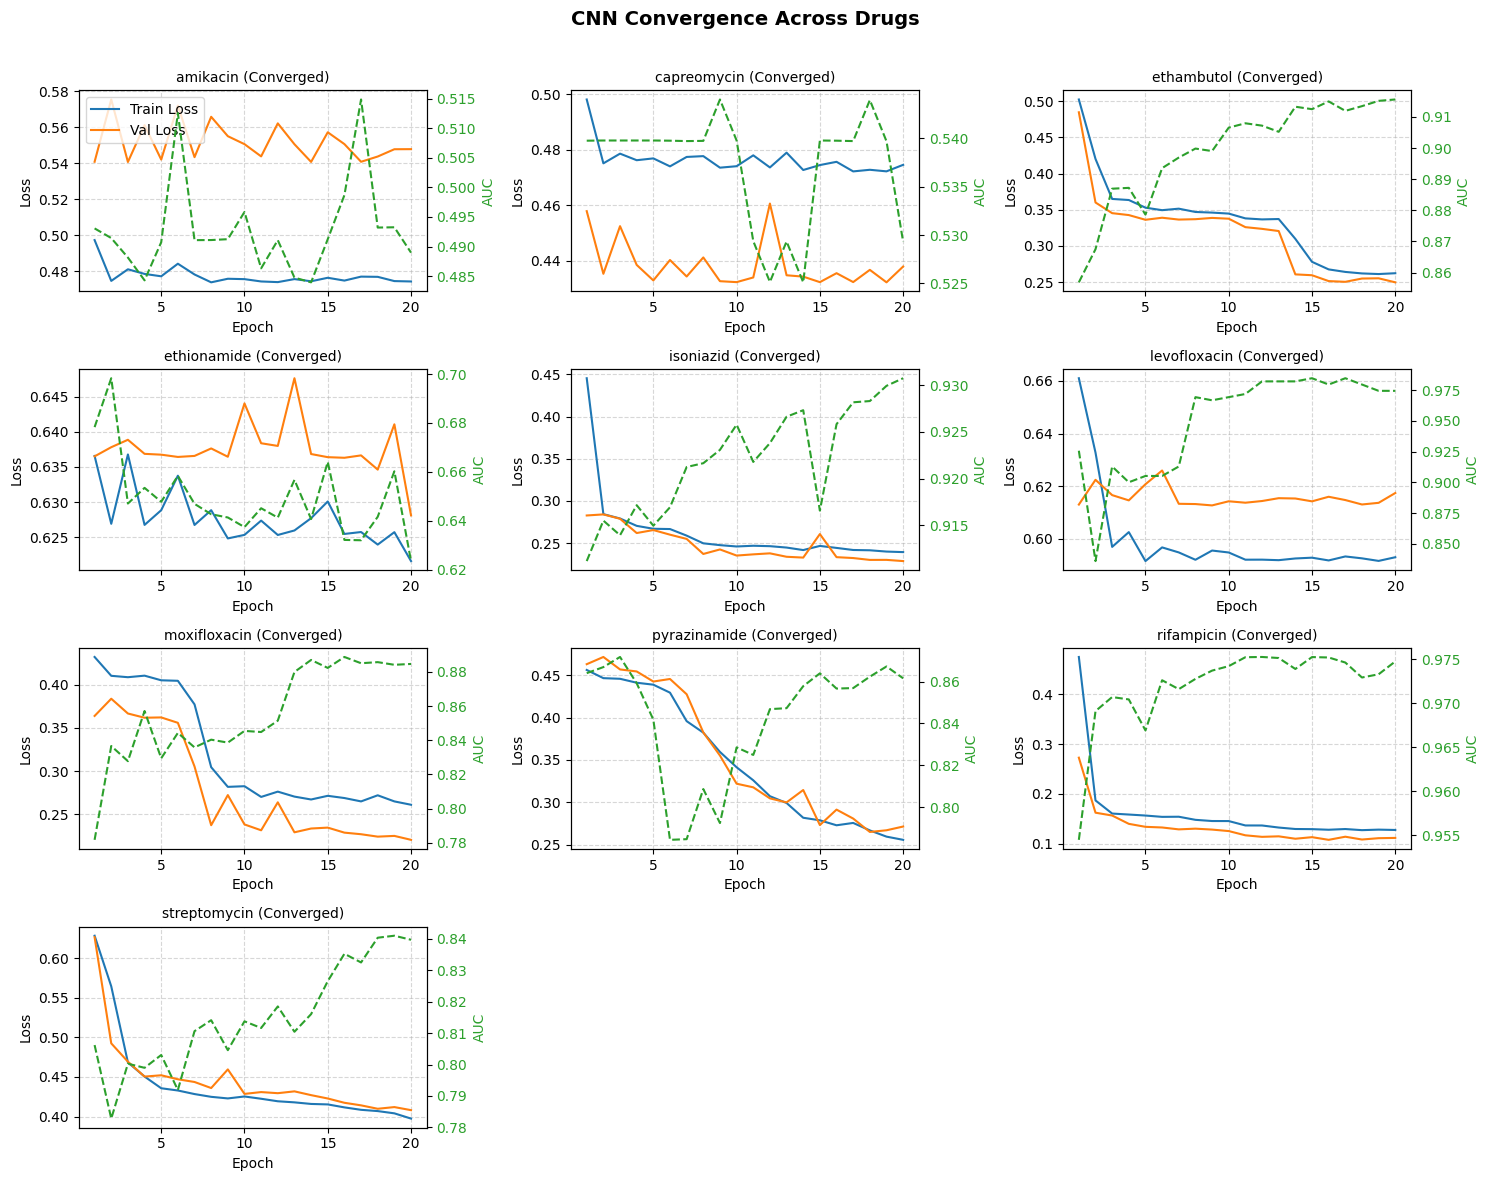

📉 Convergence grid saved → ../data/latest/results/prediction/cnn/cnn_convergence_grid.png


In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
BASE_DIR = Path("../data/latest/results/prediction/cnn")
OUT_CSV = BASE_DIR / "cnn_convergence_summary.csv"
OUT_PLOT = BASE_DIR / "cnn_convergence_grid.png"

# ------------------------------------------------------------------
# Helper function to check convergence
# ------------------------------------------------------------------
def check_convergence(df: pd.DataFrame, loss_col="Val_Loss", window=3, tol=1e-3):
    """Return qualitative convergence note from last few epochs."""
    if loss_col not in df.columns or len(df) < window:
        return "Unknown"

    tail = df[loss_col].iloc[-window:]
    change = tail.max() - tail.min()

    if change < tol:
        return "Stable"
    elif df[loss_col].iloc[-1] <= df[loss_col].min() * 1.05:
        return "Converged"
    else:
        return "Unstable"

# ------------------------------------------------------------------
# Collect all curve files
# ------------------------------------------------------------------
records = []
curve_data = {}   # store dfs for plotting

for csv_file in sorted(BASE_DIR.glob("*_training_curve.csv")):
    try:
        df = pd.read_csv(csv_file)
        tag = csv_file.stem.replace("_training_curve", "")
        n_epochs = df["Epoch"].max()

        # Identify columns
        val_loss_col = "Val_Loss" if "Val_Loss" in df.columns else "Loss"
        val_auc_col = "Val_AUC" if "Val_AUC" in df.columns else "AUC"

        # Check convergence
        status = check_convergence(df, loss_col=val_loss_col)

        final = df.iloc[-1]
        records.append({
            "Drug": tag,
            "Epochs": n_epochs,
            "Train_Loss": final.get("Train_Loss", float("nan")),
            "Val_Loss": final.get(val_loss_col, float("nan")),
            "Val_AUC": final.get(val_auc_col, float("nan")),
            "Val_Acc": final.get("Val_Acc", float("nan")),
            "Convergence_Status": status,
        })

        curve_data[tag] = df

    except Exception as e:
        print(f"⚠️ Could not read {csv_file.name}: {e}")

# ------------------------------------------------------------------
# Save summary CSV
# ------------------------------------------------------------------
if not records:
    print("❌ No CNN training curve files found under:", BASE_DIR)
    exit()

summary_df = pd.DataFrame(records)
summary_df.to_csv(OUT_CSV, index=False)
print(f"✅ Convergence summary saved → {OUT_CSV}")

# ------------------------------------------------------------------
# Multi-panel convergence plot
# ------------------------------------------------------------------
n = len(curve_data)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3))
axes = axes.flatten()

for i, (drug, df) in enumerate(curve_data.items()):
    ax = axes[i]
    # plot loss
    if "Train_Loss" in df.columns and "Val_Loss" in df.columns:
        ax.plot(df["Epoch"], df["Train_Loss"], label="Train Loss", color="tab:blue")
        ax.plot(df["Epoch"], df["Val_Loss"], label="Val Loss", color="tab:orange")
        ax.set_ylabel("Loss")
    elif "Loss" in df.columns:
        ax.plot(df["Epoch"], df["Loss"], label="Loss", color="tab:blue")

    # plot AUC on right axis if available
    if "Val_AUC" in df.columns or "AUC" in df.columns:
        auc_col = "Val_AUC" if "Val_AUC" in df.columns else "AUC"
        ax2 = ax.twinx()
        ax2.plot(df["Epoch"], df[auc_col], color="tab:green", linestyle="--", label="Val AUC")
        ax2.set_ylabel("AUC", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")

    status = summary_df.loc[summary_df["Drug"] == drug, "Convergence_Status"].iloc[0]
    ax.set_title(f"{drug} ({status})", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.5)
    if i == 0:
        ax.legend(loc="upper left")

# clean empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("CNN Convergence Across Drugs", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_PLOT, dpi=250)
plt.show()
plt.close(fig)

print(f"📉 Convergence grid saved → {OUT_PLOT}")


## step 7: precision and recall

In [19]:
# pr_from_shap_COMBINED_cnn.py
# ------------------------------------------------------------
import pandas as pd, numpy as np
from pathlib import Path

# ─── 0. Global knobs ---------------------------------------------------
K_VALUES      = [1, 5, 10]
ALLOWED_CONF  = ['1) Assoc w R', '2) Assoc w R - Interim']

DATA_DIR      = Path("../data")                                        # root
SHAP_DIR      = Path("../data/latest/results/interpretability/cnn")    # *.pkl here
CATALOG_CSV   = DATA_DIR / "filtered_variants_output.csv"
OUT_DIR       = SHAP_DIR / "pr_tables"; OUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── 0-b.  Drug → genes map (same map you train with) -----------------
DRUG2GENES = {
    "rifampicin"  : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"],
    "moxifloxacin": ["gyrA","gyrB"],
    "levofloxacin": ["gyrA","gyrB"],
    "isoniazid"   : ["katG","inhA"],
    "streptomycin": ["rpsL","gid"],
    "ethambutol"  : ["embC","embA","embB"],
    "ethionamide" : ["ethA","ethR","inhA"],
}

# ─── 1. WHO catalogue (precompute utilities) --------------------------
catalog = pd.read_csv(CATALOG_CSV)
catalog["aa_pos_0idx"] = catalog["aa_pos"].astype(int) - 1
catalog["_gene_norm"]  = catalog["gene"].astype(str).str.lower().str.strip()

def who_sets_for_genes(cat_df, genes):
    """Return (gold_pairs, excl_pairs) as sets of (gene_norm, aa_pos_0idx) across all genes."""
    genes_norm = {g.lower().strip() for g in genes}
    sub = cat_df[cat_df["_gene_norm"].isin(genes_norm)].copy()

    is_bona = sub["confidence"].isin(ALLOWED_CONF) & (sub["intersectional"] == True)
    gold = set(zip(sub.loc[is_bona, "_gene_norm"], sub.loc[is_bona, "aa_pos_0idx"]))

    is_unc_or_notI = (sub["confidence"] == "3) Uncertain significance") | (sub["intersectional"] != True)
    excl_all = set(zip(sub.loc[is_unc_or_notI, "_gene_norm"], sub.loc[is_unc_or_notI, "aa_pos_0idx"]))
    excl = excl_all - gold  # never exclude bona-fide sites
    return gold, excl

# ─── 2. Build a single per-drug ranking from SHAP ---------------------
def combined_rank_from_shap(shap_df, genes):
    """
    Combine per-gene SHAP into one per-drug list:
      rows: gene, aa_pos_0idx, score=max_abs_SHAP_across_isolates
    """
    rows = []
    multi = len(genes) > 1
    for g in genes:
        col = f"importance_{g}" if multi else "importance_full"
        if col not in shap_df.columns:
            print(f"  [warn] missing column {col}; skipping gene {g}")
            continue
        stacks = np.stack([np.asarray(v).squeeze() for v in shap_df[col]], axis=0)  # (E, Lg)
        maximp = np.abs(stacks).max(axis=0)
        Lg = len(maximp)
        rows.append(pd.DataFrame({
            "gene": [g]*Lg,
            "aa_pos_0idx": np.arange(Lg, dtype=int),
            "score": maximp.astype(float),
        }))
    if not rows:
        return pd.DataFrame(columns=["gene","aa_pos_0idx","score"])
    comb = pd.concat(rows, ignore_index=True)
    comb["_gene_norm"] = comb["gene"].astype(str).str.lower().str.strip()
    comb = comb.sort_values(["score","_gene_norm","aa_pos_0idx"],
                            ascending=[False, True, True]).reset_index(drop=True)
    comb["rank1"] = np.arange(1, len(comb)+1)
    return comb

def greedy_topk_pairs(rank_df, k, excl_pairs):
    """Pick top-k (gene,pos) from the combined ranking, skipping WHO-excluded pairs."""
    chosen = []
    for _, r in rank_df.iterrows():
        pair = (r["_gene_norm"], int(r["aa_pos_0idx"]))
        if pair in excl_pairs:
            continue
        chosen.append(pair)
        if len(chosen) == k:
            break
    return chosen

# ─── 3. Driver per drug (pooled across genes) -------------------------
all_rows = []
for drug, genes in DRUG2GENES.items():
    # file produced by compute_shap_onehot(..., model_tag="cnn_ohe")
    shap_pkl = SHAP_DIR / f"{drug}_cnn_shap_all.pkl"
    if not shap_pkl.exists():
        print(f"[skip] {drug}: SHAP file missing → {shap_pkl}")
        continue

    shap_df = pd.read_pickle(shap_pkl)
    print(f"\n{drug.upper()}  (genes pooled: {', '.join(genes)})")

    # Combined per-drug ranking
    rank_df = combined_rank_from_shap(shap_df, genes)
    if rank_df.empty:
        print(f"  [warn] no usable SHAP columns for {drug}; skipping.")
        continue

    # WHO gold/exclusions across ALL genes of this drug
    gold_pairs, excl_pairs = who_sets_for_genes(catalog, genes)
    K_gold = len(gold_pairs)

    # Save combined ranked list for plots/reuse
    out_rank = OUT_DIR / f"{drug}_ranked_SHAP_COMBINED.csv"
    rank_df[["gene","aa_pos_0idx","score","rank1"]].to_csv(out_rank, index=False)

    # Evaluate at k ∈ {1,5,10}
    for k in K_VALUES:
        topk_pairs = greedy_topk_pairs(rank_df, k, excl_pairs)
        k_eff = len(topk_pairs)
        tp = len(set(topk_pairs) & gold_pairs)

        prec = tp / k_eff if k_eff else 0.0
        rec  = tp / K_gold if K_gold else 0.0
        f1   = 2*prec*rec/(prec+rec+1e-8) if (prec+rec) else 0.0

        # List matched bona-fide variants (unique by gene+pos)
        if k_eff and K_gold:
            cat_pick = catalog[
                catalog["_gene_norm"].isin([g.lower() for g in genes]) &
                catalog["confidence"].isin(ALLOWED_CONF) &
                (catalog["intersectional"] == True)
            ].copy()
            cat_pick["_pair"] = list(zip(cat_pick["_gene_norm"], cat_pick["aa_pos_0idx"].astype(int)))
            hits_list = (cat_pick[cat_pick["_pair"].isin(set(topk_pairs))]
                         .drop_duplicates(["_pair"]))["variant"].astype(str).tolist() or ["None"]
        else:
            hits_list = ["None"]

        all_rows.append({
            "drug": drug,
            "gene": "ALL",                # pooled across genes
            "k_req": k,
            "k_eff": k_eff,
            "total_res_pos": K_gold,      # |gold_pairs|
            "TP": tp,
            "precision": prec,
            "recall": rec,
            "F1": f1,
            "hit_variants": ", ".join(hits_list),
        })

# ─── 4. aggregate & write CSV -----------------------------------------
summary = pd.DataFrame(all_rows)
out_csv = OUT_DIR / "precision_recall_all_drugs_COMBINED.csv"
summary.to_csv(out_csv, index=False)
print("\nTable saved →", out_csv)



RIFAMPICIN  (genes pooled: rpoB)

PYRAZINAMIDE  (genes pooled: pncA)

CAPREOMYCIN  (genes pooled: tlyA)

AMIKACIN  (genes pooled: eis)

MOXIFLOXACIN  (genes pooled: gyrA, gyrB)

LEVOFLOXACIN  (genes pooled: gyrA, gyrB)

ISONIAZID  (genes pooled: katG, inhA)

STREPTOMYCIN  (genes pooled: rpsL, gid)

ETHAMBUTOL  (genes pooled: embC, embA, embB)

ETHIONAMIDE  (genes pooled: ethA, ethR, inhA)

Table saved → ../data/latest/results/interpretability/cnn/pr_tables/precision_recall_all_drugs_COMBINED.csv


In [11]:
# # pr_from_shap.py
# # ------------------------------------------------------------
# import pandas as pd, numpy as np
# from pathlib import Path
# from functools import reduce

# # ─── 0. Global knobs ---------------------------------------------------
# K_VALUES      = [1, 5, 10]
# ALLOWED_CONF  = ['1) Assoc w R', '2) Assoc w R - Interim']

# DATA_DIR      = Path("../data")                                # root
# SHAP_DIR      = Path("../data/latest/results/interpretability/cnn")                      # *.pkl here
# CATALOG_CSV   = DATA_DIR / "filtered_variants_output.csv"
# OUT_DIR       = SHAP_DIR/"pr_tables"; OUT_DIR.mkdir(parents=True, exist_ok=True)

# # ─── 0-b.  Drug → genes map (same map  train with) -----------------
# DRUG2GENES = {
#     "rifampicin"  : ["rpoB"],
#     "pyrazinamide": ["pncA"],
#     "capreomycin" : ["tlyA"],
#     "amikacin"    : ["eis"],
#     "moxifloxacin": ["gyrA","gyrB"],
#     "levofloxacin": ["gyrA","gyrB"],
#     "isoniazid"   : ["katG","inhA"],
#     "streptomycin": ["rpsL","gid"],
#     "ethambutol"  : ["embC","embA","embB"],   # corrected order
#     "ethionamide" : ["ethA","ethR","inhA"],
# }

# # ─── 1. Load WHO catalogue once ---------------------------------------
# catalog = pd.read_csv(CATALOG_CSV)
# catalog["aa_pos_0idx"] = catalog["aa_pos"].astype(int) - 1  # zero-based

# def bona_fide(cat_rows):
#     m = cat_rows["confidence"].isin(ALLOWED_CONF) & (cat_rows["intersectional"] == True)
#     return set(cat_rows.loc[m, "aa_pos_0idx"])

# # def exclusion(cat_rows):
# #     m = (cat_rows["confidence"] == "3) Uncertain significance") | (cat_rows["intersectional"] != True)
# #     return set(cat_rows.loc[m, "aa_pos_0idx"])
# def exclusion(cat_rows):
#     mask_unc   = cat_rows["confidence"] == "3) Uncertain significance"
#     mask_not_i = cat_rows["intersectional"] != True
#     excl = set(cat_rows.loc[mask_unc | mask_not_i, "aa_pos_0idx"])
#     return excl - bona_fide(cat_rows)          # ← keep bona-fide sites

# def rows_for_gene(g):   # convenience
#     return catalog[catalog["gene"].str.lower() == g.lower()]

# # ─── 2. helper: rank residues by max|SHAP| across isolates -------------
# def rank_by_max_abs(shap_df, col):
#     stacks = np.stack([np.asarray(v).squeeze() for v in shap_df[col]], axis=0)  # (N,L)
#     maximp = np.abs(stacks).max(axis=0)
#     return (pd.DataFrame({"Residue_Position": np.arange(len(maximp)),
#                           "MaxAbsSHAP": maximp})
#             .sort_values("MaxAbsSHAP", ascending=False)
#             .reset_index(drop=True))

# def greedy_topk(rank_df, k, exclude):
#     chosen=[]
#     for pos in rank_df["Residue_Position"]:
#         if pos in exclude:   # skip excluded sites
#             continue
#         chosen.append(pos)
#         if len(chosen)==k:
#             break
#     return chosen

# # ─── 3. driver per drug -----------------------------------------------
# all_rows = []
# for drug, genes in DRUG2GENES.items():
#     shap_pkl = SHAP_DIR / f"{drug}_cnn_ohe_shap_all.pkl"
#     if not shap_pkl.exists():
#         print(f"[skip] {drug}: SHAP file missing."); continue

#     shap_df = pd.read_pickle(shap_pkl)
        
#     print(f"\n{drug.upper()}  (genes: {', '.join(genes)})")

#     for g in genes:
#         col_name = f"importance_{g}" if len(genes)>1 else "importance_full"

#         if col_name not in shap_df.columns:
#             print(f"  [warn] {col_name} col not found → skip"); continue

#         rank_df    = rank_by_max_abs(shap_df, col_name)
#         cat_rows   = rows_for_gene(g)
#         gold_sites = bona_fide(cat_rows)
#         excl_sites = exclusion(cat_rows)
#         n_true     = len(gold_sites)

#         for k in K_VALUES:
#             topk   = greedy_topk(rank_df, k, exclude=excl_sites)
#             k_eff  = len(topk)
#             tp     = len(gold_sites & set(topk))
#             prec   = tp / k_eff if k_eff else 0.0
#             rec    = tp / n_true if n_true else 0.0
#             f1     = 2*prec*rec/(prec+rec+1e-8) if (prec+rec) else 0.0

#             hits = (cat_rows[cat_rows["aa_pos_0idx"].isin(topk) &
#                              cat_rows["confidence"].isin(ALLOWED_CONF) &
#                              (cat_rows["intersectional"] == True)]
#                     .drop_duplicates("aa_pos_0idx")["variant"].tolist() or ["None"])

#             all_rows.append({
#                 "drug":drug, "gene":g, "k_req":k, "k_eff":k_eff,
#                 "total_res_pos": n_true, "TP":tp,
#                 "precision":prec, "recall":rec, "F1":f1,
#                 "hit_variants": ", ".join(hits)
#             })
#         # optional: save per-gene ranking for further plots
#         rank_df.to_csv(OUT_DIR / f"{drug}_{g}_ranked_SHAP.csv", index=False)

# # ─── 4. aggregate & write CSV -----------------------------------------
# summary = pd.DataFrame(all_rows)
# summary.to_csv(OUT_DIR / "precision_recall_all_drugs_shapall.csv", index=False)
# print("\ntable saved →", OUT_DIR/"precision_recall_all_drugs.csv")



RIFAMPICIN  (genes: rpoB)

PYRAZINAMIDE  (genes: pncA)

CAPREOMYCIN  (genes: tlyA)

AMIKACIN  (genes: eis)

MOXIFLOXACIN  (genes: gyrA, gyrB)

LEVOFLOXACIN  (genes: gyrA, gyrB)

ISONIAZID  (genes: katG, inhA)

STREPTOMYCIN  (genes: rpsL, gid)

ETHAMBUTOL  (genes: embC, embA, embB)

ETHIONAMIDE  (genes: ethA, ethR, inhA)

table saved → ../data/latest/results/interpretability/cnn/pr_tables/precision_recall_all_drugs.csv


In [1]:
import pandas as pd
from pathlib import Path
import glob
import re


def gather_run_metrics(runs_root="../data/latest/results/prediction/cnn",
                       history_glob="*_train_test_auc.csv",
                       save_as="cnn_train_test_auc.csv",
                       keep_last=True):
    """
    Walk through <runs_root>/**/<history_glob>, extract train + test aucs



    Returns
    -------
    pandas.DataFrame with columns:
        run_dir, gene, dim, dim_type, best_auc, epoch_at_best,
        [last_auc, last_epoch]
    """
    runs_root = Path(runs_root)
    history_files = glob.glob(str(runs_root / history_glob), recursive=True)

    if not history_files:
        raise FileNotFoundError(f"No history CSVs found under {runs_root}")

    rows = []

    # Pattern: captures 'gene' and the (type+dim) suffix
    rx_folder = re.compile(r"(?P<drug>[A-Za-z0-9_])")

    for csv_path in history_files:
        csv_path = Path(csv_path)
        run_dir = csv_path.parent

        m = rx_folder.match(run_dir.name)
        if not m:
            print(f"[!] Skipping unrecognized folder: {run_dir.name}")
            continue

        # drug = m.group("drug")

        df = pd.read_csv(csv_path)
        drug = df['Drug'][0]
        if df.empty or "Test_AUC" not in df.columns:
            print(f"[!] Skipping malformed CSV: {csv_path}")
            continue

        # best_row = df.loc[df["val_auc"].idxmax()]
        entry = {
            "run_dir": run_dir.name,
            "drug": drug,
            "train_auc": df['Train_AUC'][0],
            "test_auc": df['Test_AUC'][0]
            # "best_auc": best_row["val_auc"],
            # "epoch_at_best": int(best_row["epoch"]),
        }

        # if keep_last:
        #     entry["last_auc"] = df["val_auc"].iloc[-1]
        #     entry["last_epoch"] = int(df["epoch"].iloc[-1])

        rows.append(entry)

    master = pd.DataFrame(rows).sort_values(["drug"])
    out_file = runs_root / save_as
    master.to_csv(out_file, index=False)
    print(f"Combined {len(rows)} runs → {out_file}")

    return master


# Example call
summary = gather_run_metrics(runs_root="../data/latest/results/prediction/cnn",
                             save_as="cnn_train_test_auc.csv")
print(summary.head())



Combined 10 runs → ../data/latest/results/prediction/cnn/cnn_train_test_auc.csv
  run_dir         drug  train_auc  test_auc
7     cnn     amikacin   0.500324  0.494291
6     cnn  capreomycin   0.514471  0.516119
2     cnn   ethambutol   0.917401  0.909449
0     cnn  ethionamide   0.608689  0.587909
5     cnn    isoniazid   0.927065  0.914553
